# Mental Health Prediction (EDA + ML)

## Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

sns.set()

## Load Dataset

In [8]:
df = pd.read_csv(r"depression_dataset_reddit_cleaned.csv")
df.head()

,clean_text,is_depression
0,we understand that most people who reply immed...,1
1,welcome to r depression s check in post a plac...,1
2,anyone else instead of sleeping more when depr...,1
3,i ve kind of stuffed around a lot in my life d...,1
4,sleep is my greatest and most comforting escap...,1


## Dataset Overview

In [9]:
df.shape

(7731, 2)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7731 entries, 0 to 7730
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_text     7731 non-null   object
 1   is_depression  7731 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 120.9+ KB


In [11]:
df.describe(include="all")

,clean_text,is_depression
count,7731,7731.000000
unique,7650,NaN
top,being border restricted victim day by day we g...,NaN
freq,8,NaN
mean,NaN,0.495537
std,NaN,0.500012
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,0.000000
75%,NaN,1.000000


## Check Missing Values

In [12]:
df.isnull().sum()

clean_text       0
is_depression    0
dtype: int64

## Class Distribution

In [13]:
df['is_depression'].value_counts()

is_depression
0    3900
1    3831
Name: count, dtype: int64

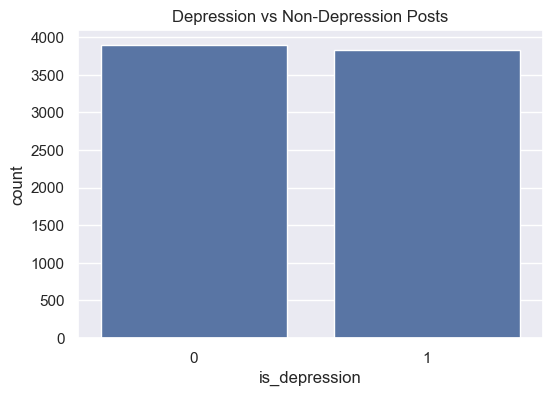

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_depression', data=df)
plt.title("Depression vs Non-Depression Posts")
plt.show()

## Text Cleaning

In [15]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df['clean_text'] = df['clean_text'].apply(clean_text)
df.head()

,clean_text,is_depression
0,we understand that most people who reply immed...,1
1,welcome to r depression s check in post a plac...,1
2,anyone else instead of sleeping more when depr...,1
3,i ve kind of stuffed around a lot in my life d...,1
4,sleep is my greatest and most comforting escap...,1


## Text Length Analysis

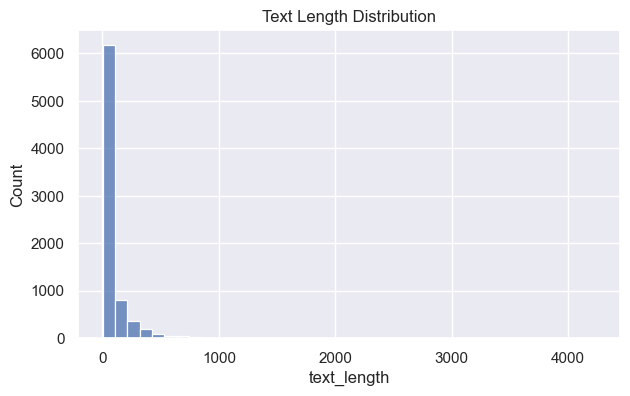

In [16]:
df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(7,4))
sns.histplot(df['text_length'], bins=40)
plt.title("Text Length Distribution")
plt.show()

## Length vs Depression

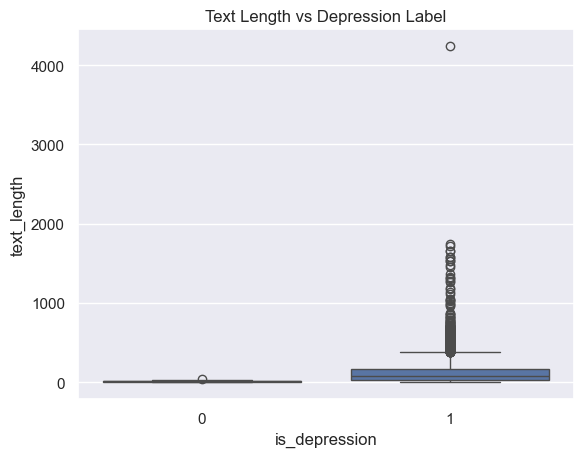

In [17]:
sns.boxplot(x='is_depression', y='text_length', data=df)
plt.title("Text Length vs Depression Label")
plt.show()

 # **Machine Learning Implementation**

## TF-IDF Vectorization

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])
y = df['is_depression']

X.shape

(7731, 5000)

## Train-Test Split

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Models

In [22]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

nb = MultinomialNB()
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier()

nb.fit(X_train, y_train)
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Evaluate Models

In [23]:
from sklearn.metrics import classification_report

print("Naive Bayes:")
print(classification_report(y_test, nb.predict(X_test)))

print("Logistic Regression:")
print(classification_report(y_test, lr.predict(X_test)))

print("Random Forest:")
print(classification_report(y_test, rf.predict(X_test)))

Naive Bayes:
              precision    recall  f1-score   support

           0       0.97      0.80      0.88       783
           1       0.83      0.98      0.90       764

    accuracy                           0.89      1547
   macro avg       0.90      0.89      0.89      1547
weighted avg       0.90      0.89      0.89      1547

Logistic Regression:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       783
           1       0.98      0.93      0.95       764

    accuracy                           0.95      1547
   macro avg       0.96      0.95      0.95      1547
weighted avg       0.96      0.95      0.95      1547

Random Forest:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       783
           1       1.00      0.91      0.95       764

    accuracy                           0.95      1547
   macro avg       0.96      0.95      0.95      1547
weighted avg       0.96  

## Confusion Matrix

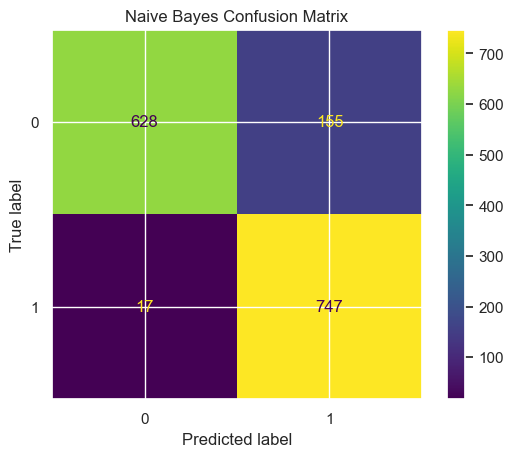

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(nb, X_test, y_test)
plt.title("Naive Bayes Confusion Matrix")
plt.show()

## Accuracy Comparision

In [25]:
from sklearn.metrics import accuracy_score

print("NB Accuracy:", accuracy_score(y_test, nb.predict(X_test)))
print("LR Accuracy:", accuracy_score(y_test, lr.predict(X_test)))
print("RF Accuracy:", accuracy_score(y_test, rf.predict(X_test)))

NB Accuracy: 0.8888170652876535
LR Accuracy: 0.9547511312217195
RF Accuracy: 0.9547511312217195


In [28]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [29]:
import os
print(os.getcwd())

C:\Users\Dell
